In [31]:
# Imports
import gzip
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
# read in file

file_loc = "/Users/gregduckworth/Git/CoCT/ds_code_challenge/notebooks/data/sr_hex.csv.gz"
df = pd.read_csv(file_loc, compression="gzip")

# OK, the file has been read in. Let's inspect it for various metrics and populations, and distributions. 

In [17]:
df.shape

(941634, 16)

In [18]:
df.head()

,notification_number,reference_number,creation_timestamp,completion_timestamp,directorate,department,branch,section,code_group,code,cause_code_group,cause_code,official_suburb,latitude,longitude,h3_level8_index
0,400583534,9.109492e+09,2020-10-07 06:55:18+02:00,2020-10-08 15:36:35+02:00,URBAN MOBILITY,Roads Infrastructure Management,RIM Area Central,District: Blaauwberg,TD Customer complaint groups,Pothole&Defect Road Foot Bic Way/Kerbs,Road (RCL),Wear and tear,MONTAGUE GARDENS,-33.872839,18.522488,88ad360225fffff
1,400555043,9.108995e+09,2020-07-09 16:08:13+02:00,2020-07-14 14:27:01+02:00,URBAN MOBILITY,Roads Infrastructure Management,RIM Area East,District : Somerset West,TD Customer complaint groups,Manhole Cover/Gully Grid,Road (RCL),Vandalism,SOMERSET WEST,-34.078916,18.848940,88ad36d5e1fffff
2,400589145,9.109614e+09,2020-10-27 10:21:59+02:00,2020-10-28 17:48:15+02:00,URBAN MOBILITY,Roads Infrastructure Management,RIM Area East,District : Somerset West,TD Customer complaint groups,Manhole Cover/Gully Grid,Road (RCL),Vandalism,STRAND,-34.102242,18.821116,88ad36d437fffff
3,400538915,9.108601e+09,2020-03-19 06:36:06+02:00,2021-03-29 20:34:19+02:00,URBAN MOBILITY,Roads Infrastructure Management,RIM Area North,District : Bellville,TD Customer complaint groups,Paint Markings Lines&Signs,Road Markings,Wear and tear,RAVENSMEAD,-33.920019,18.607209,88ad361133fffff
4,400568554,NaN,2020-08-25 09:48:42+02:00,2020-08-31 08:41:13+02:00,URBAN MOBILITY,Roads Infrastructure Management,RIM Area South,District : Athlone,TD Customer complaint groups,Pothole&Defect Road Foot Bic Way/Kerbs,Road (RCL),Surfacing failure,CLAREMONT,-33.987400,18.453760,88ad361709fffff


In [38]:
df.isna().sum()

notification_number          0
reference_number        348714
creation_timestamp           0
completion_timestamp     12192
directorate               9435
department                9454
branch                   28401
section                  93125
code_group                   0
code                         0
cause_code_group        810517
cause_code              811965
official_suburb         212413
latitude                212364
longitude               212364
h3_level8_index              0
dtype: int64

So we have a dataset that links a Service Request ("notification_number", "reference_number", "creation_timestamp") to the time it was completed ("completion_timestamp"), with info around the type of request in what appears to be a heirarchical manner ("directorate", "branch", "code_group", "code", "cause_code_group", "cause_code"), along with some spatial information around the service request ("latitude", "longitude", "h3_level8_index"). 

Let's inspect if there are any 

Wow! Many more NAs that I was expecting. 
- reference number not strictly needed for analysis, so can leave it.
- I'll need completion timestamp to calculate time to resolve issues, so must remove NAs here
- remove NAs in directorate and department (as there are few)
- section is location, and I have this info so i can ignore
- Many NAs in cause_code and cause, will remove and ignore.
- I need lat and long to plot through space, so will remove NAs here. 

# Implementation

In [23]:
# Remove NAs in the lat and longs -- keep the rest 

dfx = df[(~df['latitude'].isna()) & (~df['longitude'].isna())]
dfx.shape

(729270, 16)

In [24]:
941634 - 729270 # 212364 -- lat and long pairs are missing, not individual lat and long values -- good. 

212364

In [43]:
# Remove the rest of the NAs
dfy = dfx[(~dfx['directorate'].isna()) & 
          (~dfx['department'].isna()) & 
          (~dfx['completion_timestamp'].isna()) & 
          (~dfx['branch'].isna()) & 
          (~dfx['department'].isna()) & 
          (~dfx['department'].isna()) & 
          (~dfx['department'].isna())]

In [ ]:
dfy.isna().sum()

In [47]:
dfz = dfy[['notification_number','creation_timestamp','completion_timestamp','directorate','department','code_group', 
        'code', 'latitude', 'longitude', 'h3_level8_index']]
dfz.head()

,notification_number,creation_timestamp,completion_timestamp,directorate,department,code_group,code,latitude,longitude,h3_level8_index
0,400583534,2020-10-07 06:55:18+02:00,2020-10-08 15:36:35+02:00,URBAN MOBILITY,Roads Infrastructure Management,TD Customer complaint groups,Pothole&Defect Road Foot Bic Way/Kerbs,-33.872839,18.522488,88ad360225fffff
1,400555043,2020-07-09 16:08:13+02:00,2020-07-14 14:27:01+02:00,URBAN MOBILITY,Roads Infrastructure Management,TD Customer complaint groups,Manhole Cover/Gully Grid,-34.078916,18.848940,88ad36d5e1fffff
2,400589145,2020-10-27 10:21:59+02:00,2020-10-28 17:48:15+02:00,URBAN MOBILITY,Roads Infrastructure Management,TD Customer complaint groups,Manhole Cover/Gully Grid,-34.102242,18.821116,88ad36d437fffff
3,400538915,2020-03-19 06:36:06+02:00,2021-03-29 20:34:19+02:00,URBAN MOBILITY,Roads Infrastructure Management,TD Customer complaint groups,Paint Markings Lines&Signs,-33.920019,18.607209,88ad361133fffff
4,400568554,2020-08-25 09:48:42+02:00,2020-08-31 08:41:13+02:00,URBAN MOBILITY,Roads Infrastructure Management,TD Customer complaint groups,Pothole&Defect Road Foot Bic Way/Kerbs,-33.987400,18.453760,88ad361709fffff


In [60]:
# So let's engineer some features -- firstly - time to resolve query
dfz['creation_timestamp'] = pd.to_datetime(dfz['creation_timestamp'])
dfz['completion_timestamp'] = pd.to_datetime(dfz['completion_timestamp'])
dfz['completion_time_hours'] = (dfz['completion_timestamp'] - dfz['creation_timestamp']).dt.total_seconds() / 3600


# Example: aggregate per hex
per_hex = df.groupby('h3_level8_index').agg(
    # total number of service requests
    num_requests=('notification_number', 'count'),

    # num direct
    num_directorates = ('directorate', 'count'),
    
    # number of unique code groups
    unique_code_groups=('code_group', 'nunique'),
    
    # number of unique cause codes
    unique_cause_codes=('cause_code', 'nunique'),
    
    # average completion time in hours
    avg_completion_time=('completion_time_hours', 'mean'),
    
    # standard deviation of completion time
    #std_completion_time=('completion_time_hours', 'std')
).reset_index()

per_hex = per_hex[per_hex['h3_level8_index'] != "0"]
per_hex

,h3_level8_index,num_requests,num_directorates,unique_code_groups,unique_cause_codes,avg_completion_time
1,88ad360001fffff,170,167,14,9,625.109103
2,88ad360003fffff,50,48,8,5,344.519717
3,88ad360005fffff,599,591,16,14,497.491804
4,88ad360007fffff,412,408,16,17,553.048364
5,88ad36000bfffff,1,1,1,1,458.792500
...,...,...,...,...,...,...
2078,88ad36d73bfffff,148,148,11,5,1326.806047
2079,88ad36d73dfffff,115,113,8,2,584.052065
2080,88bc696c87fffff,1,0,1,0,195.155000
2081,88bc696cabfffff,4,4,2,0,335.409792


In [61]:
# Let's scale these:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(per_hex[['num_requests', 'num_directorates', 'unique_code_groups', 'unique_cause_codes', 'avg_completion_time']])

In [67]:
cols = ['num_requests', 'num_directorates', 'unique_code_groups', 'unique_cause_codes', 'avg_completion_time']

# Convert back to DataFrame with column names
per_hex_scaled = pd.DataFrame(features_scaled, columns=[f"{c}_scaled" for c in cols])

# Optional: keep the h3 hex index
per_hex_scaled['h3_level8_index'] = per_hex['h3_level8_index'].values

# Now per_hex_scaled is easy to inspect and combine
print(per_hex_scaled.head())

   num_requests_scaled  num_directorates_scaled  unique_code_groups_scaled  \
0             0.044310                 0.043913                       0.52   
1             0.012847                 0.012622                       0.28   
2             0.156791                 0.155404                       0.60   
3             0.107761                 0.107284                       0.60   
4             0.000000                 0.000263                       0.00   

   unique_cause_codes_scaled  avg_completion_time_scaled  h3_level8_index  
0                   0.195652                    0.048505  88ad360001fffff  
1                   0.108696                    0.026731  88ad360003fffff  
2                   0.304348                    0.038602  88ad360005fffff  
3                   0.369565                    0.042913  88ad360007fffff  
4                   0.021739                    0.035599  88ad36000bfffff  


In [70]:
# So let's think about some scale? relatively speaking, so 
per_hex_scaled['overall_scaling'] = (per_hex_scaled['num_requests_scaled'] * 0.6 + 
                                    per_hex_scaled['avg_completion_time_scaled'] * 0.6 + 
                                    per_hex_scaled['num_directorates_scaled'] * 0.3 + 
                                    per_hex_scaled['unique_code_groups_scaled'] * 0.1 + 
                                    per_hex_scaled['unique_cause_codes_scaled'] * 0.1)

per_hex_scaled['overall_scaling'].describe()

count    2072.000000
mean        0.175405
std         0.146611
min         0.000079
25%         0.055880
50%         0.148017
75%         0.256382
max         1.103158
Name: overall_scaling, dtype: float64

In [72]:
per_hex_scaled['classification'] = np.where(per_hex_scaled['overall_scaling'] > 0.148, 1, 0)


In [102]:
# dfz[~dfz[['latitude','longitude','h3_level8_index']].duplicated()]
dfa = dfz[['latitude','longitude','h3_level8_index']]
df[df['h3_level8_index'] == "88ad360225fffff"]

# per_hex_scaled_coords = pd.merge(per_hex_scaled, dfz[['latitude','longitude','h3_level8_index']], left_on = "h3_level8_index", right_on = "h3_level8_index", how = "left")

,notification_number,reference_number,creation_timestamp,completion_timestamp,directorate,department,branch,section,code_group,code,cause_code_group,cause_code,official_suburb,latitude,longitude,h3_level8_index,completion_time_hours
0,400583534,9.109492e+09,2020-10-07 06:55:18+02:00,2020-10-08 15:36:35+02:00,URBAN MOBILITY,Roads Infrastructure Management,RIM Area Central,District: Blaauwberg,TD Customer complaint groups,Pothole&Defect Road Foot Bic Way/Kerbs,Road (RCL),Wear and tear,MONTAGUE GARDENS,-33.872839,18.522488,88ad360225fffff,32.688056
37538,1015466763,9.108196e+09,2020-01-02 13:41:22+02:00,2020-01-07 08:52:19+02:00,URBAN WASTE MANAGEMENT,Solid Waste Management,Collections,Collections,SOLID WASTE,Non-Collection of 240L Bin,NaN,NaN,MONTAGUE GARDENS,-33.870291,18.528962,88ad360225fffff,115.182500
58322,1015490003,9.108232e+09,2020-01-10 07:58:23+02:00,2020-02-19 15:12:53+02:00,WATER AND SANITATION,Distribution Services,Reticulation,Reticulation Water Distribution,WATER,Leak at Fire Hydrant,NaN,NaN,MONTAGUE GARDENS,-33.873691,18.523848,88ad360225fffff,967.241667
58994,1015490755,9.108233e+09,2020-01-10 09:55:41+02:00,2020-02-19 15:53:04+02:00,WATER AND SANITATION,Distribution Services,Reticulation,Reticulation Water Distribution,WATER,No Water Supply,NaN,NaN,MONTAGUE GARDENS,-33.868284,18.521016,88ad360225fffff,965.956389
64232,1015496637,9.108243e+09,2020-01-13 10:28:45+02:00,2020-01-24 10:28:38+02:00,WATER AND SANITATION,Distribution Services,Reticulation,Reticulation Water Distribution,WATER,No Water Supply,NaN,NaN,MONTAGUE GARDENS,-33.868284,18.521016,88ad360225fffff,263.998056
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
854200,1016405888,9.109801e+09,2020-11-26 16:21:08+02:00,2020-11-27 07:11:53+02:00,WATER AND SANITATION,Distribution Services,Reticulation,Reticulation Water Distribution,WATER,Low Water Pressure,NaN,NaN,MONTAGUE GARDENS,-33.874340,18.527466,88ad360225fffff,14.845833
856770,1016408814,NaN,2020-11-27 15:04:43+02:00,2020-11-27 15:28:01+02:00,WATER AND SANITATION,Commercial Services,Customer Services (Water),Debt Management,WATER AND SANITATION OR METER QUERIES,Customer : Reconnection Request,NaN,NaN,MONTAGUE GARDENS,-33.869393,18.527792,88ad360225fffff,0.388333
860459,1016413127,9.109814e+09,2020-11-30 09:44:35+02:00,2020-12-03 13:07:45+02:00,WATER AND SANITATION,Distribution Services,Reticulation,Reticulation Water Distribution,WATER,No Water Supply,NaN,NaN,MONTAGUE GARDENS,-33.874012,18.527647,88ad360225fffff,75.386111
861012,1016413766,9.109816e+09,2020-11-30 11:13:32+02:00,2021-01-27 11:13:34+02:00,WATER AND SANITATION,Distribution Services,Reticulation,Reticulation Water Distribution,WATER,No Water Supply,NaN,NaN,MONTAGUE GARDENS,-33.873318,18.527153,88ad360225fffff,1392.000556


In [79]:
per_hex_scaled_coords

,num_requests_scaled,num_directorates_scaled,unique_code_groups_scaled,unique_cause_codes_scaled,avg_completion_time_scaled,h3_level8_index,overall_scaling,classification,latitude,longitude
0,0.044310,0.043913,0.52,0.195652,0.048505,88ad360001fffff,0.140428,0,-33.834129,18.494760
1,0.044310,0.043913,0.52,0.195652,0.048505,88ad360001fffff,0.140428,0,-33.837898,18.498139
2,0.044310,0.043913,0.52,0.195652,0.048505,88ad360001fffff,0.140428,0,-33.837902,18.498420
3,0.044310,0.043913,0.52,0.195652,0.048505,88ad360001fffff,0.140428,0,-33.833564,18.493929
4,0.044310,0.043913,0.52,0.195652,0.048505,88ad360001fffff,0.140428,0,-33.833351,18.496059
...,...,...,...,...,...,...,...,...,...,...
704338,0.000787,0.001052,0.04,0.000000,0.026024,88bc696cabfffff,0.020402,0,-34.228517,18.850096
704339,0.000787,0.001052,0.04,0.000000,0.026024,88bc696cabfffff,0.020402,0,-34.228517,18.850096
704340,0.000787,0.001052,0.04,0.000000,0.026024,88bc696cabfffff,0.020402,0,-34.228517,18.850096
704341,0.000787,0.001052,0.04,0.000000,0.026024,88bc696cabfffff,0.020402,0,-34.228517,18.850096


In [80]:
per_hex_scaled

,num_requests_scaled,num_directorates_scaled,unique_code_groups_scaled,unique_cause_codes_scaled,avg_completion_time_scaled,h3_level8_index,overall_scaling,classification
0,0.044310,0.043913,0.52,0.195652,0.048505,88ad360001fffff,0.140428,0
1,0.012847,0.012622,0.28,0.108696,0.026731,88ad360003fffff,0.066403,0
2,0.156791,0.155404,0.60,0.304348,0.038602,88ad360005fffff,0.254291,1
3,0.107761,0.107284,0.60,0.369565,0.042913,88ad360007fffff,0.219546,1
4,0.000000,0.000263,0.00,0.021739,0.035599,88ad36000bfffff,0.023612,0
...,...,...,...,...,...,...,...,...
2077,0.038542,0.038917,0.40,0.108696,0.102956,88ad36d73bfffff,0.147444,0
2078,0.029890,0.029713,0.28,0.043478,0.045319,88ad36d73dfffff,0.086387,0
2079,0.000000,0.000000,0.00,0.000000,0.015141,88bc696c87fffff,0.009084,0
2080,0.000787,0.001052,0.04,0.000000,0.026024,88bc696cabfffff,0.020402,0


In [91]:
# Map back
# !pip install geopandas
import geopandas as gpd

# Path to your file
file_path = "/Users/gregduckworth/Git/CoCT/ds_code_challenge/notebooks/data/city-hex-polygons-8.geojson"

# Read the GeoJSON into a GeoDataFrame
hex_gdf = gpd.read_file(file_path)

# Inspect the first few rows
print(hex_gdf.head())

# Check columns
print(hex_gdf.columns)

# Check the number of hexes
print(f"Number of hexes: {len(hex_gdf)}")


             index  centroid_lat  centroid_lon  \
0  88ad361801fffff    -33.859427     18.677843   
1  88ad361803fffff    -33.855696     18.668766   
2  88ad361805fffff    -33.855263     18.685959   
3  88ad361807fffff    -33.851532     18.676881   
4  88ad361809fffff    -33.867322     18.678806   

                                            geometry  
0  POLYGON ((18.68119 -33.8633, 18.68357 -33.8592...  
1  POLYGON ((18.67211 -33.85957, 18.6745 -33.8555...  
2  POLYGON ((18.68931 -33.85914, 18.69169 -33.855...  
3  POLYGON ((18.68023 -33.85541, 18.68261 -33.851...  
4  POLYGON ((18.68215 -33.8712, 18.68454 -33.8671...  
Index(['index', 'centroid_lat', 'centroid_lon', 'geometry'], dtype='str')
Number of hexes: 3832


In [103]:
phx = pd.merge(per_hex_scaled, hex_gdf, left_on = "h3_level8_index", right_on = "index", how = "left")

In [97]:
phs = gpd.GeoDataFrame(phx, geometry='geometry')
phs

,num_requests_scaled,num_directorates_scaled,unique_code_groups_scaled,unique_cause_codes_scaled,avg_completion_time_scaled,h3_level8_index,overall_scaling,classification,index,centroid_lat,centroid_lon,geometry
0,0.044310,0.043913,0.52,0.195652,0.048505,88ad360001fffff,0.140428,0,88ad360001fffff,-33.836215,18.494066,"POLYGON ((18.4974 -33.84009, 18.49979 -33.8360..."
1,0.012847,0.012622,0.28,0.108696,0.026731,88ad360003fffff,0.066403,0,88ad360003fffff,-33.832471,18.485002,"POLYGON ((18.48834 -33.83635, 18.49073 -33.832..."
2,0.156791,0.155404,0.60,0.304348,0.038602,88ad360005fffff,0.254291,1,88ad360005fffff,-33.832062,18.502176,"POLYGON ((18.50552 -33.83594, 18.5079 -33.8319..."
3,0.107761,0.107284,0.60,0.369565,0.042913,88ad360007fffff,0.219546,1,88ad360007fffff,-33.828319,18.493112,"POLYGON ((18.49645 -33.8322, 18.49884 -33.8281..."
4,0.000000,0.000263,0.00,0.021739,0.035599,88ad36000bfffff,0.023612,0,88ad36000bfffff,-33.840366,18.485955,"POLYGON ((18.48929 -33.84425, 18.49168 -33.840..."
...,...,...,...,...,...,...,...,...,...,...,...,...
2077,0.038542,0.038917,0.40,0.108696,0.102956,88ad36d73bfffff,0.147444,0,88ad36d73bfffff,-34.142960,18.876697,"POLYGON ((18.88006 -34.14682, 18.88244 -34.142..."
2078,0.029890,0.029713,0.28,0.043478,0.045319,88ad36d73dfffff,0.086387,0,88ad36d73dfffff,-34.142512,18.893934,"POLYGON ((18.89729 -34.14637, 18.89968 -34.142..."
2079,0.000000,0.000000,0.00,0.000000,0.015141,88bc696c87fffff,0.009084,0,88bc696c87fffff,-34.234508,18.844780,"POLYGON ((18.84814 -34.23836, 18.85053 -34.234..."
2080,0.000787,0.001052,0.04,0.000000,0.026024,88bc696cabfffff,0.020402,0,88bc696cabfffff,-34.230359,18.852915,"POLYGON ((18.85628 -34.23422, 18.85866 -34.230..."


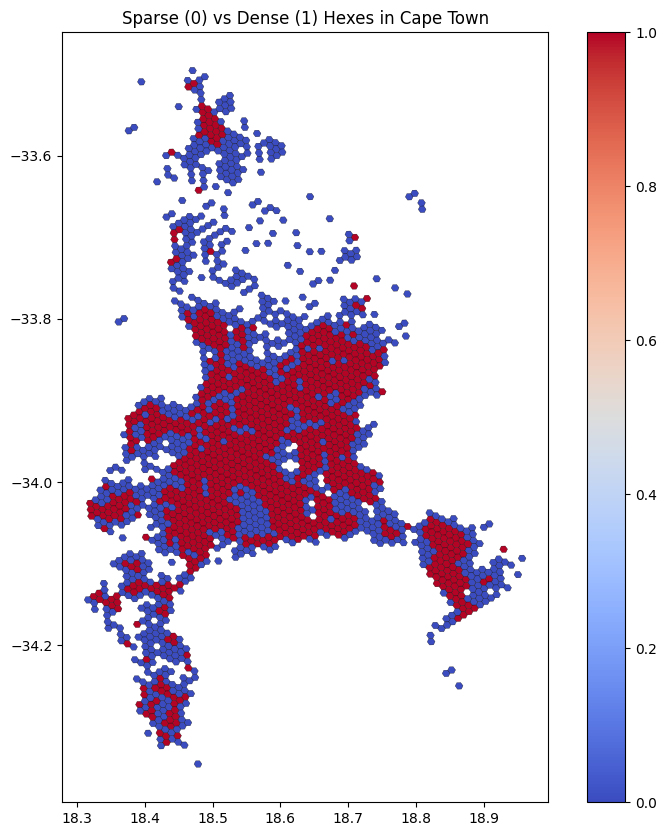

In [100]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,10))
phs.plot(
    column='classification',       # 0=sparse, 1=dense
    cmap='coolwarm',
    legend=True,
    ax=ax,
    edgecolor='black',             # only works for GeoDataFrame
    linewidth=0.2
)
ax.set_title("Sparse (0) vs Dense (1) Hexes in Cape Town")
plt.show()

In [ ]:
# Which ones are unusual? Let's see if we can id any -- get suburb back on this

In [108]:
# one to one relationship between suburb and hex?
rel =  df.groupby('h3_level8_index')['official_suburb'].nunique().reset_index(name='unique_count')
rel['unique_count'].describe()

count    2083.000000
mean        2.113778
std         1.403309
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         9.000000
Name: unique_count, dtype: float64

In [109]:
rel =  df.groupby('h3_level8_index')['section'].nunique().reset_index(name='unique_count')
rel['unique_count'].describe()

count    2083.000000
mean       13.623620
std         9.704098
min         0.000000
25%         3.000000
50%        15.000000
75%        22.000000
max        84.000000
Name: unique_count, dtype: float64

In [113]:
# going to have to just merge back and duplicate:
unique_combos = df[['h3_level8_index', 'official_suburb']].drop_duplicates()
unique_combos

,h3_level8_index,official_suburb
0,88ad360225fffff,MONTAGUE GARDENS
1,88ad36d5e1fffff,SOMERSET WEST
2,88ad36d437fffff,STRAND
3,88ad361133fffff,RAVENSMEAD
4,88ad361709fffff,CLAREMONT
...,...,...
937618,88ad36026dfffff,ACACIA PARK
938420,88ad360143fffff,DE GRENDEL FARM
940468,88ad36182bfffff,VREDEKLOOF
940595,88ad361895fffff,CAPE FARMS - DISTRICT C


In [118]:
# 
inspect_classifier = pd.merge(phx, unique_combos, left_on = "h3_level8_index", right_on = "h3_level8_index", how = "left")
# Aything with Rural in its name is probably going to be sparsely populated
rural_mask = inspect_classifier['official_suburb'].str.contains("rural", case=False, na=False)
rural_areas = inspect_classifier[rural_mask]
rural_areas 

,num_requests_scaled,num_directorates_scaled,unique_code_groups_scaled,unique_cause_codes_scaled,avg_completion_time_scaled,h3_level8_index,overall_scaling,classification,index,centroid_lat,centroid_lon,geometry,official_suburb
3866,0.001835,0.002104,0.08,0.000000,0.014791,88ad36c645fffff,0.018607,0,88ad36c645fffff,-34.066440,18.780849,"POLYGON ((18.7842 -34.07031, 18.78659 -34.0662...",FIRGROVE RURAL
3873,0.000787,0.001052,0.00,0.000000,0.035519,88ad36c64dfffff,0.022099,0,88ad36c64dfffff,-34.074316,18.781817,"POLYGON ((18.78517 -34.07818, 18.78756 -34.074...",FIRGROVE RURAL
3890,0.109072,0.109650,0.48,0.217391,0.073333,88ad36c661fffff,0.212077,1,88ad36c661fffff,-34.054406,18.788007,"POLYGON ((18.79136 -34.05827, 18.79375 -34.054...",FIRGROVE RURAL
3899,0.005244,0.005522,0.12,0.021739,0.188634,88ad36c66dfffff,0.132157,0,88ad36c66dfffff,-34.058125,18.797102,"POLYGON ((18.80046 -34.06199, 18.80284 -34.057...",FIRGROVE RURAL
4186,0.008915,0.008940,0.44,0.043478,0.057669,88ad36d583fffff,0.090980,0,88ad36d583fffff,-34.073438,18.816264,"POLYGON ((18.81962 -34.0773, 18.82201 -34.0732...",FIRGROVE RURAL
4202,0.016256,0.016566,0.44,0.043478,0.116120,88ad36d58bfffff,0.132743,0,88ad36d58bfffff,-34.081313,18.817233,"POLYGON ((18.82059 -34.08518, 18.82298 -34.081...",FIRGROVE RURAL
4205,0.000524,0.000789,0.04,0.000000,0.104940,88ad36d591fffff,0.067515,0,88ad36d591fffff,-34.073878,18.799039,"POLYGON ((18.80239 -34.07774, 18.80478 -34.073...",FIRGROVE RURAL
4206,0.000000,0.000263,0.00,0.000000,0.007607,88ad36d595fffff,0.004643,0,88ad36d595fffff,-34.069720,18.807167,"POLYGON ((18.81052 -34.07358, 18.81291 -34.069...",FIRGROVE RURAL
4207,0.002360,0.002630,0.04,0.000000,0.152558,88ad36d59dfffff,0.097739,0,88ad36d59dfffff,-34.077596,18.808136,"POLYGON ((18.81149 -34.08146, 18.81388 -34.077...",FIRGROVE RURAL
4245,0.004982,0.005259,0.24,0.000000,0.008945,88ad36d5b3fffff,0.033934,0,88ad36d5b3fffff,-34.053967,18.805228,"POLYGON ((18.80858 -34.05783, 18.81097 -34.053...",FIRGROVE RURAL


Most are 0, but 88ad36c661fffff is dense! let's check it out:

In [119]:
rural_areas[rural_areas['index'] == "88ad36c661fffff"]

,num_requests_scaled,num_directorates_scaled,unique_code_groups_scaled,unique_cause_codes_scaled,avg_completion_time_scaled,h3_level8_index,overall_scaling,classification,index,centroid_lat,centroid_lon,geometry,official_suburb
3890,0.109072,0.10965,0.48,0.217391,0.073333,88ad36c661fffff,0.212077,1,88ad36c661fffff,-34.054406,18.788007,"POLYGON ((18.79136 -34.05827, 18.79375 -34.054...",FIRGROVE RURAL


In [ ]:
# num requests scaled is higher than the others, that's why. So maybe we could work on the scaling. 

In [121]:
[print(k) for k in inspect_classifier['official_suburb']]

FLAMINGO VLEI
TABLE VIEW
TABLE VIEW
TABLE VIEW
FLAMINGO VLEI
TABLE VIEW
FLAMINGO VLEI
MILNERTON
TABLE VIEW
FLAMINGO VLEI
TABLE VIEW
TABLE VIEW
WEST RIDING
PARKLANDS
SUNRIDGE
PARKLANDS
TABLE VIEW
PARKLANDS
WEST RIDING
TABLE VIEW
PARKLANDS
TABLE VIEW
WEST RIDING
SUNRIDGE
TABLE VIEW
WEST RIDING
SUNRIDGE
CAPE FARMS - DISTRICT B
TABLE VIEW
BLOUBERG RISE
TABLE VIEW
BLOUBERGRANT
BLOUBERGRANT
WEST BEACH
TABLE VIEW
PARKLANDS
SUNNINGDALE
BLOUBERG RISE
TABLE VIEW
BLOUBERG RISE
BLOUBERG SANDS
WEST BEACH
SUNNINGDALE
TABLE VIEW
TABLE VIEW
BLOUBERGRANT
TABLE VIEW
PARKLANDS
MILNERTON RIDGE
ROYAL ASCOT
MILNERTON
SUNSET BEACH
MILNERTON
MILNERTON RIDGE
ROYAL ASCOT
MILNERTON
MONTAGUE GARDENS
MILNERTON
MILNERTON
ROYAL ASCOT
MARCONI BEAM
MILNERTON
ROYAL ASCOT
SUNSET BEACH
MILNERTON RIDGE
MONTAGUE GARDENS
ROYAL ASCOT
MILNERTON
MARCONI BEAM
SUNSET BEACH
SUNSET BEACH
TABLE VIEW
MILNERTON
FLAMINGO VLEI
TABLE VIEW
CAPE FARMS - DISTRICT B
MILNERTON
TABLE VIEW
SUNRIDGE
CAPE FARMS - DISTRICT B
MILNERTON
MONTAGUE GA

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,

In [122]:
inspect_classifier[inspect_classifier['official_suburb'] == 'SUNNINGDALE']

,num_requests_scaled,num_directorates_scaled,unique_code_groups_scaled,unique_cause_codes_scaled,avg_completion_time_scaled,h3_level8_index,overall_scaling,classification,index,centroid_lat,centroid_lon,geometry,official_suburb
36,0.114840,0.114646,0.68,0.282609,0.048838,88ad360035fffff,0.228861,1,88ad360035fffff,-33.812526,18.491205,"POLYGON ((18.49454 -33.81641, 18.49693 -33.812...",SUNNINGDALE
42,0.156004,0.155141,0.72,0.282609,0.055840,88ad360037fffff,0.273910,1,88ad360037fffff,-33.808782,18.482144,"POLYGON ((18.48548 -33.81266, 18.48787 -33.808...",SUNNINGDALE
153,0.069481,0.068893,0.56,0.195652,0.038261,88ad360189fffff,0.160878,1,88ad360189fffff,-33.788830,18.488346,"POLYGON ((18.49168 -33.79271, 18.49407 -33.788...",SUNNINGDALE
157,0.063450,0.063371,0.52,0.108696,0.013747,88ad36018bfffff,0.128199,0,88ad36018bfffff,-33.785086,18.479285,"POLYGON ((18.48262 -33.78897, 18.48501 -33.784...",SUNNINGDALE
164,0.131883,0.131475,0.56,0.239130,0.047291,88ad3601c3fffff,0.226860,1,88ad3601c3fffff,-33.796730,18.489299,"POLYGON ((18.49264 -33.80061, 18.49502 -33.796...",SUNNINGDALE
170,0.200839,0.200631,0.60,0.326087,0.048694,88ad3601c9fffff,0.302518,1,88ad3601c9fffff,-33.808372,18.499315,"POLYGON ((18.50265 -33.81225, 18.50504 -33.808...",SUNNINGDALE
171,0.141059,0.140678,0.68,0.347826,0.043943,88ad3601cbfffff,0.255987,1,88ad3601cbfffff,-33.804628,18.490252,"POLYGON ((18.49359 -33.80851, 18.49598 -33.804...",SUNNINGDALE
181,0.107236,0.106758,0.52,0.217391,0.037455,88ad3601d5fffff,0.192582,1,88ad3601d5fffff,-33.792985,18.480238,"POLYGON ((18.48358 -33.79687, 18.48596 -33.792...",SUNNINGDALE
184,0.006555,0.006837,0.20,0.000000,0.090273,88ad3601d7fffff,0.080148,0,88ad3601d7fffff,-33.789240,18.471178,"POLYGON ((18.47452 -33.79312, 18.4769 -33.7891...",SUNNINGDALE
191,0.119560,0.118328,0.64,0.260870,0.060886,88ad3601ddfffff,0.233853,1,88ad3601ddfffff,-33.800884,18.481191,"POLYGON ((18.48453 -33.80476, 18.48691 -33.800...",SUNNINGDALE


In [ ]:
Looks like the two have much fewer requests submitted -- 

In [123]:
inspect_classifier[inspect_classifier['official_suburb'] == 'GUGULETU'] # Dense 

,num_requests_scaled,num_directorates_scaled,unique_code_groups_scaled,unique_cause_codes_scaled,avg_completion_time_scaled,h3_level8_index,overall_scaling,classification,index,centroid_lat,centroid_lon,geometry,official_suburb
564,0.416885,0.418091,0.64,0.326087,0.041391,88ad361001fffff,0.497002,1,88ad361001fffff,-33.972832,18.570931,"POLYGON ((18.57428 -33.9767, 18.57666 -33.9726...",GUGULETU
566,0.414525,0.414673,0.68,0.391304,0.026301,88ad361003fffff,0.496028,1,88ad361003fffff,-33.969096,18.561856,"POLYGON ((18.5652 -33.97297, 18.56759 -33.9689...",GUGULETU
571,0.141846,0.141993,0.64,0.413043,0.033939,88ad361007fffff,0.253373,1,88ad361007fffff,-33.964949,18.569974,"POLYGON ((18.57332 -33.96882, 18.5757 -33.9648...",GUGULETU
574,0.907971,0.909808,0.68,0.391304,0.031555,88ad361009fffff,0.943788,1,88ad361009fffff,-33.980714,18.571889,"POLYGON ((18.57523 -33.98459, 18.57762 -33.980...",GUGULETU
577,0.352648,0.353142,0.72,0.369565,0.030843,88ad36100bfffff,0.444994,1,88ad36100bfffff,-33.976979,18.562814,"POLYGON ((18.56616 -33.98085, 18.56854 -33.976...",GUGULETU
579,0.408233,0.409677,0.52,0.152174,0.021449,88ad36100dfffff,0.447930,1,88ad36100dfffff,-33.976567,18.580007,"POLYGON ((18.58335 -33.98044, 18.58574 -33.976...",GUGULETU
638,0.286051,0.285827,0.60,0.456522,0.031738,88ad361039fffff,0.382074,1,88ad361039fffff,-33.961213,18.560899,"POLYGON ((18.56424 -33.96509, 18.56663 -33.961...",GUGULETU
647,0.335868,0.337102,0.64,0.347826,0.032096,88ad361043fffff,0.420692,1,88ad361043fffff,-33.988595,18.572847,"POLYGON ((18.57619 -33.99247, 18.57858 -33.988...",GUGULETU
654,0.324069,0.324218,0.60,0.347826,0.027382,88ad361047fffff,0.402918,1,88ad361047fffff,-33.984448,18.580965,"POLYGON ((18.58431 -33.98832, 18.5867 -33.9843...",GUGULETU
659,0.250131,0.249540,0.60,0.217391,0.028503,88ad36104bfffff,0.323781,1,88ad36104bfffff,-33.996476,18.573805,"POLYGON ((18.57715 -34.00035, 18.57954 -33.996...",GUGULETU


In [124]:
inspect_classifier[inspect_classifier['official_suburb'] == 'MALMESBURY'] # Dense 

,num_requests_scaled,num_directorates_scaled,unique_code_groups_scaled,unique_cause_codes_scaled,avg_completion_time_scaled,h3_level8_index,overall_scaling,classification,index,centroid_lat,centroid_lon,geometry,official_suburb


In [ ]:
# Improvements on this:
# Lots of assumptions here, need to sense check that these assumptions are right
# relationship between the core vars, whats the weighting?
# include any other variables in here?
# Could include external data, such as populations (from Census ,etc), this would inform